In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
# To save models
import math
import json
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from pickle import dump

In [4]:
df = pd.read_csv("/workspaces/AnthonnyMal-Machine-Learnig/data/processed/df_diabetes")

## Split

In [5]:
# Dividimos el conjunto de datos en muestras de train y test
X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

## Nota importante

>Recordemos que esto da continuidad al proyecto 04 de arboles de decisiones. Recordare los datos para comparar pero si queremos ver de donde los conseguimos con hechar un vistazo al proyecto anterior veremos todo.
>

## Conclusiones al proyecto anterior

>Con los datos del train tenemos un 92% de precision, con los datos del test tenemos casi un 85% de precisión".
>
> Con hiperparametros lo que cambiamos fue que restamos el sobreajuste que antes era de 94% a 92%, aunque tenemos el mismo resultado en test podemos decir que al haber menos sobreajuste obtuvimos una mejora en el modelo. 

## Ramdon forest

In [6]:
model = RandomForestClassifier(random_state = 18)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

train_accuracy, test_accuracy

(1.0, 0.8424657534246576)

## Observaciones

>Con el randomForest tenemos un claro sobreajuste, Train con 100% y test con 84%. Nos sucedia antes con el arbol de decision pero lo solucionabamos con hyperparametros. lo haremos de nuevo para ver que mejoras le conseguimos.

In [8]:
param_grid = {'n_estimators': [20, 30, 50],
              'max_depth': [1, 5, 10],
              'min_samples_split': [2, 3, 5],
              'min_samples_leaf': [1, 3, 5]}

grid_search_eda = GridSearchCV(RandomForestClassifier(random_state=18),
                               param_grid,
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

grid_search_eda.fit (X_train, y_train)

grid_search_eda.best_params_

Fitting 5 folds for each of 81 candidates, totalling 405 fits


{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 50}

In [9]:
param_grid = {'n_estimators': [45, 50, 55],
              'max_depth': [1, 2, 3],
              'min_samples_split': [4, 5, 7],
              'min_samples_leaf': [4, 5, 7]}

grid_search_eda = GridSearchCV(RandomForestClassifier(random_state=18),
                               param_grid,
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

grid_search_eda.fit (X_train, y_train)

grid_search_eda.best_params_

Fitting 5 folds for each of 81 candidates, totalling 405 fits


{'max_depth': 3,
 'min_samples_leaf': 4,
 'min_samples_split': 4,
 'n_estimators': 55}

In [10]:
param_grid = {'n_estimators': [55, 100],
              'max_depth': [3, 4, 5, 6],
              'min_samples_split': [2, 3, 4,],
              'min_samples_leaf': [4]}

grid_search_eda = GridSearchCV(RandomForestClassifier(random_state=18),
                               param_grid,
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

grid_search_eda.fit (X_train, y_train)

grid_search_eda.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


{'max_depth': 6,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 100}

In [11]:
model = grid_search_eda.best_estimator_
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred_test = model.predict(X_test)

y_pred_train = model.predict(X_train)

accuracy_score(y_train, y_pred_train), accuracy_score(y_test, y_pred_test) 


(0.9397590361445783, 0.8287671232876712)

## Observaciones

>Tenemos un 94% de Train y un 83% de test con hiperparametros, nuevamente la hiperparametrizacion no nos cambio el resultado de test dramaticamente pero nos quito parte del sobreajuste que teniamos.

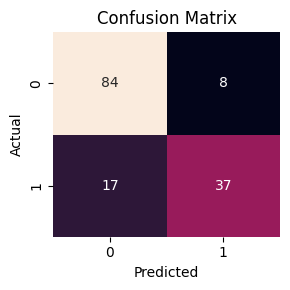

In [13]:
caso_diabetes = confusion_matrix(y_test, y_pred_test)


df_cm = pd.DataFrame(caso_diabetes)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

## Observaciones con matriz de confucion.

>Nuestro modelo acerto 84 casos negativos y 37 casos positivos de manera correcta.
>Nuestro modelo fallo 8 casos negativos (los puso como positivos) y 17 casos como positivos (los puso como negativos)

In [15]:
dump(model, open("../models/ranfor_classifier_nestimators-100_18.pkl", "wb"))